In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.datasets import make_classification
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
from scipy.spatial import Voronoi, voronoi_plot_2d
from matplotlib.patches import Patch
from matplotlib import cm

In [10]:
def evaluate_clustering(X, labels, n_clusters, ax=None, title_suffix=''):
    """
    Evaluate a clustering model using silhouette scores and the Davies-Bouldin index.
    
    Parameters:
    X (ndarray): Feature matrix.
    labels (array-like): Cluster labels assigned to each sample.
    n_clusters (int): The number of clusters in the model.
    ax: The subplot axes to plot on.
    title_suffix (str): Optional suffix for plot titlec
    
    Returns:
    None: Displays silhoutte scores and a silhouette plot.
    """
    if ax is None:
        ax = plt.gca()  # Get the current axis if none is provided
    
    # Calculate silhouette scores
    silhouette_avg = silhouette_score(X, labels)
    sample_silhouette_values = silhouette_samples(X, labels)

    # Plot silhouette analysis on the provided axis
    unique_labels = np.unique(labels)
    colormap = cm.tab10
    color_dict = {label: colormap(float(label) / n_clusters) for label in unique_labels}
    y_lower = 10
    for i in unique_labels:
        ith_cluster_silhouette_values = sample_silhouette_values[labels == i]
        ith_cluster_silhouette_values.sort()
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        color = color_dict[i]
        ax.fill_betweenx(np.arange(y_lower, y_upper),
                         0, ith_cluster_silhouette_values,
                         facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10
    
    ax.set_title(f'Silhouette Score for {title_suffix} \n' + 
                 f'Average Silhouette: {silhouette_avg:.2f}')
    ax.set_xlabel('Silhouette Coefficient')
    ax.set_ylabel('Cluster')
    ax.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax.set_xlim([-0.25, 1])  # Set the x-axis range to [0, 1]

    ax.set_yticks([])

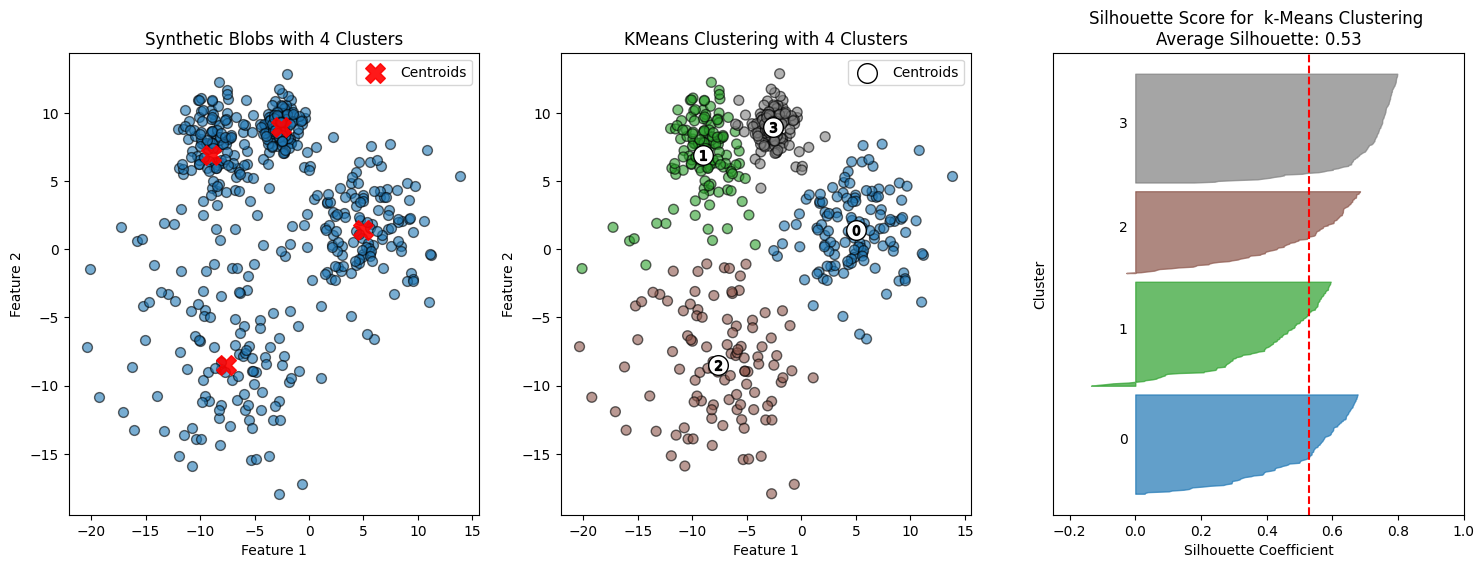

In [11]:
X, y = make_blobs(n_samples=500, n_features=2, centers=4, cluster_std=[1.0, 3, 5, 2], random_state=42)

# Apply KMeans clustering
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
y_kmeans = kmeans.fit_predict(X)

colormap = cm.tab10

# Plot the blobs
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.scatter(X[:, 0], X[:, 1], s=50, alpha=0.6, edgecolor='k')
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', alpha=0.9, label='Centroids')
plt.title(f'Synthetic Blobs with {n_clusters} Clusters')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()

# Plot the clustering result
# Create colors based on the predicted labels
colors = colormap(y_kmeans.astype(float) / n_clusters)

plt.subplot(1, 3, 2)
plt.scatter(X[:, 0], X[:, 1], c=colors, s=50, alpha=0.6, edgecolor='k')

# Label the clusters
centers = kmeans.cluster_centers_
# Draw white circles at cluster centers
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker="o",
    c="white",
    alpha=1,
    s=200,
    edgecolor="k",
    label='Centroids'
)
# Label the custer number
for i, c in enumerate(centers):
    plt.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

plt.title(f'KMeans Clustering with {n_clusters} Clusters')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()

# Evaluate the clustering
plt.subplot(1, 3, 3)
evaluate_clustering(X, y_kmeans, n_clusters, title_suffix=' k-Means Clustering')
plt.show()

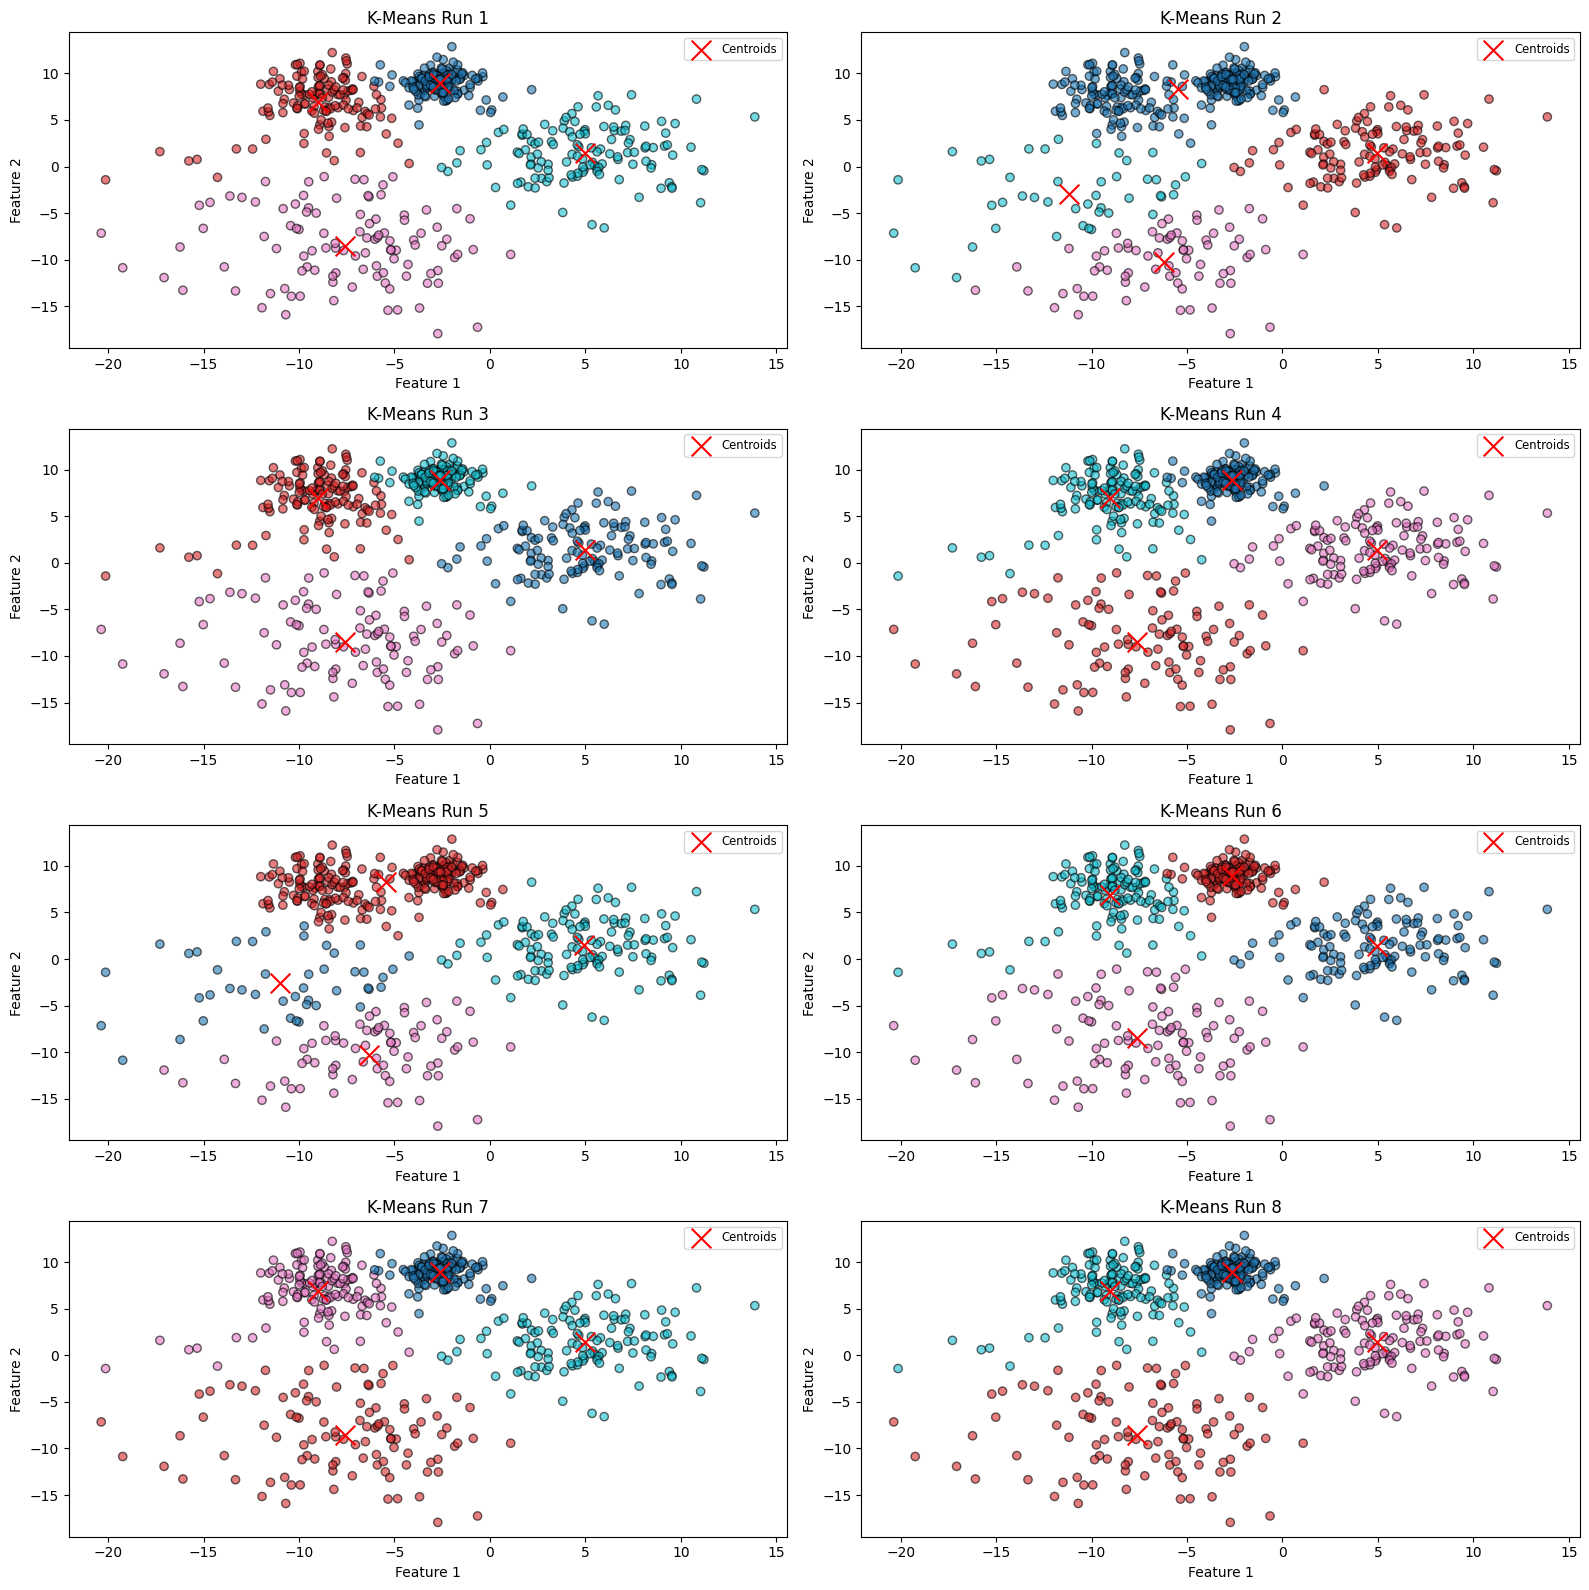

Run 1: Inertia=7633.51
Run 2: Inertia=8556.71
Run 3: Inertia=7633.51
Run 4: Inertia=7633.51
Run 5: Inertia=8556.67
Run 6: Inertia=7633.51
Run 7: Inertia=7633.51
Run 8: Inertia=7633.51


In [12]:
# Number of runs for k-means with different random states
n_runs = 8
inertia_values = []

# Calculate number of rows and columns needed for subplots
n_cols = 2 # Number of columns
n_rows = -(-n_runs // n_cols) # Ceil division to determine rows
plt.figure(figsize=(16, 16)) # Adjust the figure size for better visualization

# Run K-Means multiple times with different random states
for i in range(n_runs):
    kmeans = KMeans(n_clusters=4, random_state=None)  # Use the default `n_init`
    kmeans.fit(X)
    inertia_values.append(kmeans.inertia_)

    # Plot the clustering result
    plt.subplot(n_rows, n_cols, i + 1)
    plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='tab10', alpha=0.6, edgecolor='k')
    plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', s=200, marker='x', label='Centroids')
    plt.title(f'K-Means Run {i + 1}')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend(loc='upper right', fontsize='small')

plt.tight_layout()
plt.show()

# Print inertia values
for i, inertia in enumerate(inertia_values, start=1):
    print(f'Run {i}: Inertia={inertia:.2f}')

Conforme demonstrado pelos resultados de agrupamento, as atribuições aos clusters variam entre as execuções quando se utilizam diferentes sementes iniciais para os centroides. Além disso, os valores de inércia apresentam inconsistência, indicando que o processo de agrupamento é sensível ao posicionamento inicial dos centroides. Essa inconsistência na inércia implica um resultado menos confiável.


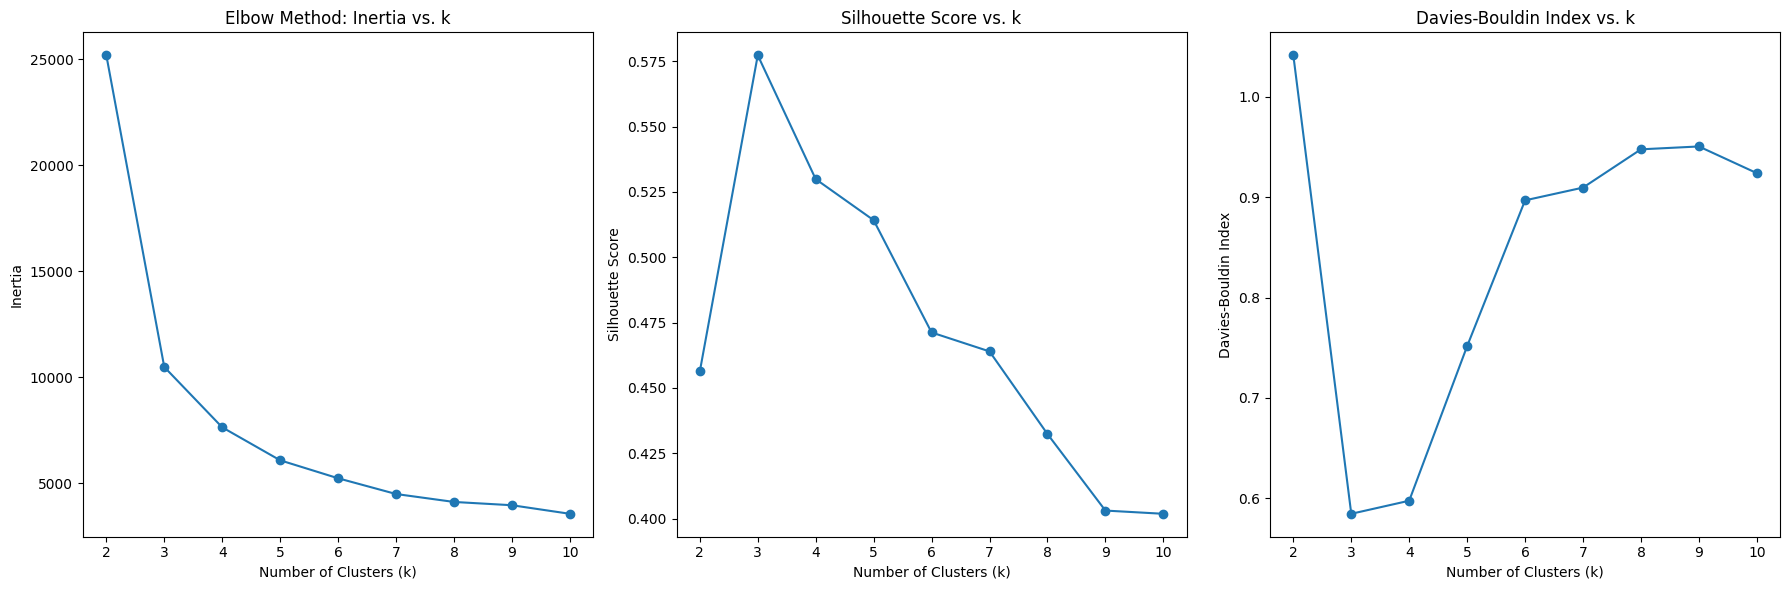

In [13]:
# Range of k values to test
k_values = range(2, 11)

# Store performance metrics
inertia_values = []
silhouette_scores = []
davies_bouldin_indices = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    y_kmeans = kmeans.fit_predict(X)
    
    # Calculate and store metrics
    inertia_values.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, y_kmeans))
    davies_bouldin_indices.append(davies_bouldin_score(X, y_kmeans))

# Plot the inertia values (Elbow Method)
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.plot(k_values, inertia_values, marker='o')
plt.title('Elbow Method: Inertia vs. k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')

# Plot silhouette scores
plt.subplot(1, 3, 2)
plt.plot(k_values, silhouette_scores, marker='o')
plt.title('Silhouette Score vs. k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')

# Plot Davies-Bouldin Index
plt.subplot(1, 3, 3)
plt.plot(k_values, davies_bouldin_indices, marker='o')
plt.title('Davies-Bouldin Index vs. k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Davies-Bouldin Index')

plt.tight_layout()
plt.show()

O primeiro gráfico é frequentemente utilizado no "método do cotovelo" (elbow method), no qual o valor ideal de k é escolhido próximo ao ponto em que a curva começa a se estabilizar. Como a inércia diminui à medida que o número de clusters aumenta, é importante encontrar o equilíbrio em que a adição de mais clusters resulta em retornos decrescentes na redução da inércia.

O gráfico de inércia aponta para um número ideal de clusters em torno de 3 ou 4. O coeficiente de silhueta (silhouette score) apresenta um pico claro em k = 3, enquanto o índice de Davies-Bouldin atinge seus valores mais baixos entre k = 3 e k = 4.

De modo geral, essas métricas sugerem que três clusters podem ser o ideal, embora saibamos que o número real de clusters, neste caso, é quatro.

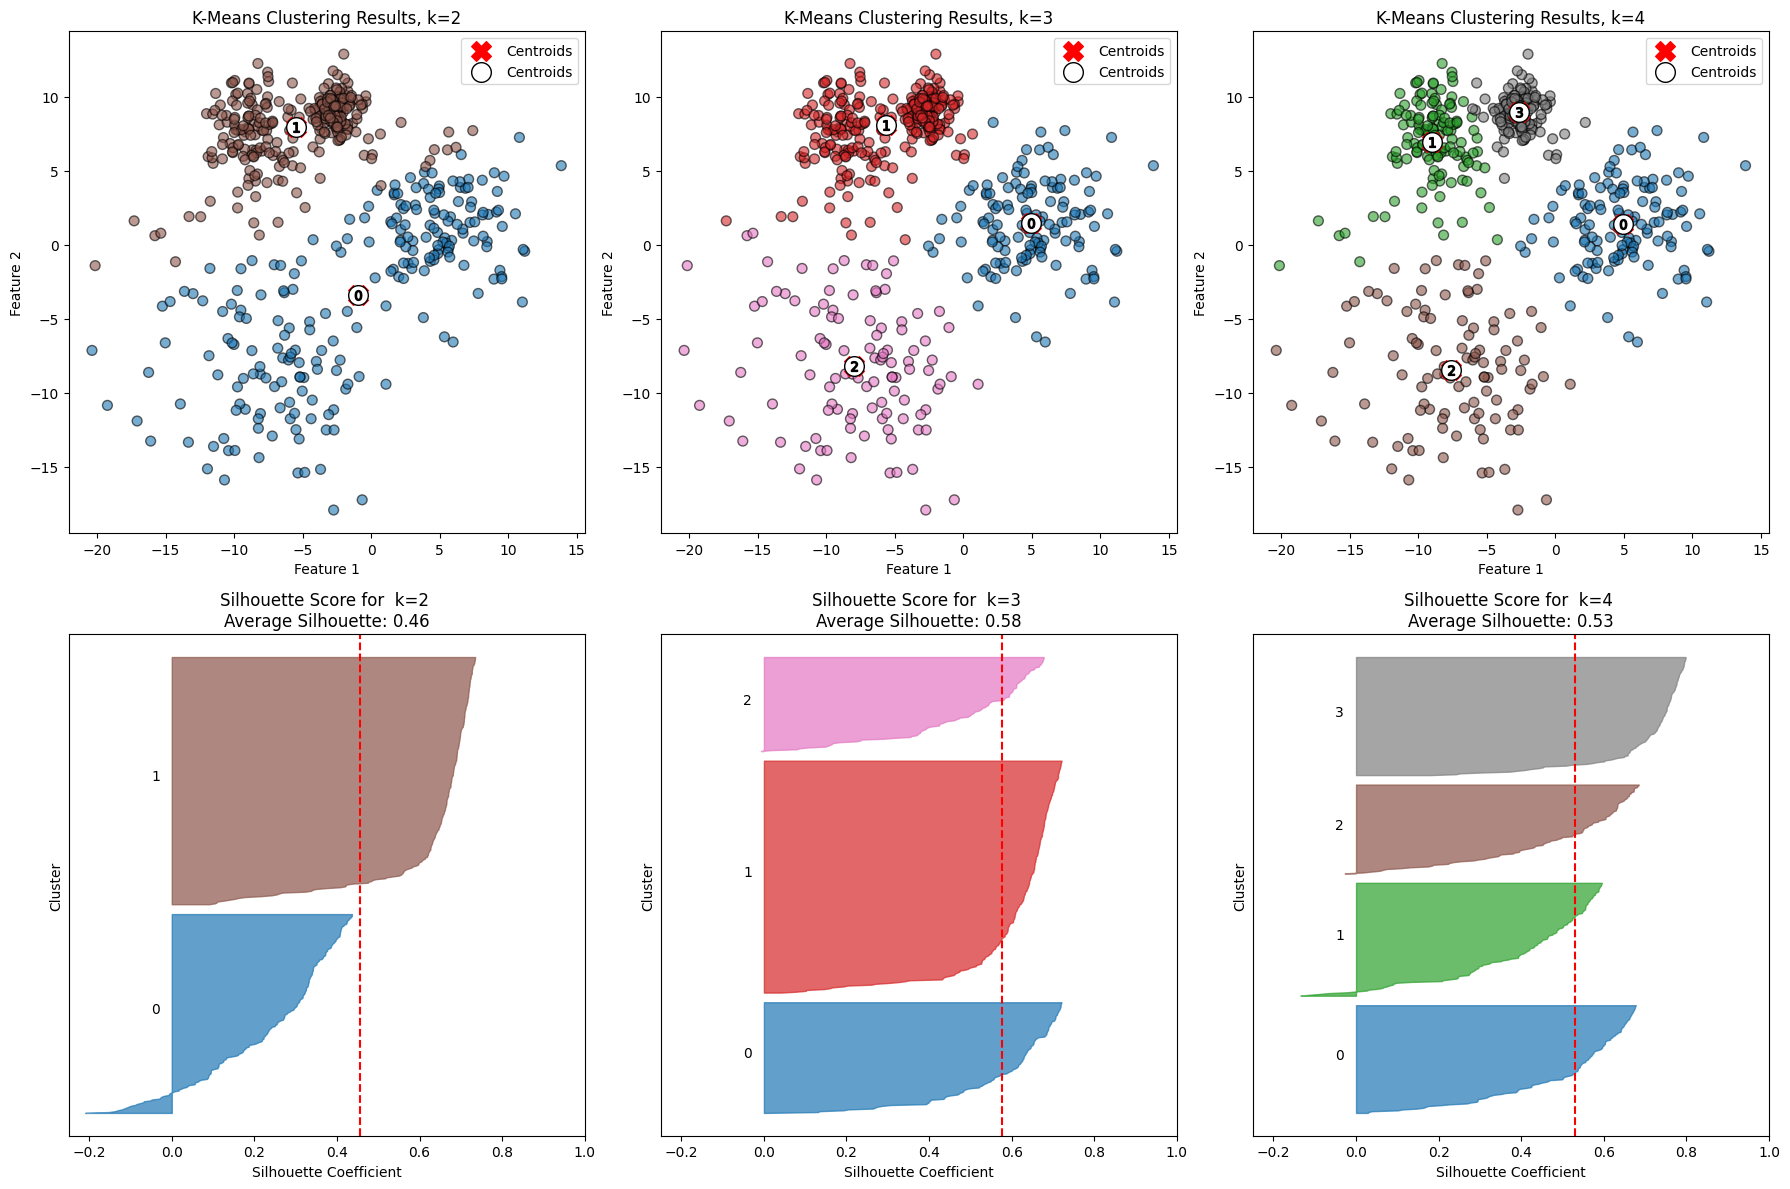

In [14]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

plt.figure(figsize=(18, 12))
colormap = cm.tab10  # Define the colormap

for i, k in enumerate([2, 3, 4]):
    # Fit KMeans and predict labels
    kmeans = KMeans(n_clusters=k, random_state=42)
    y_kmeans = kmeans.fit_predict(X)

    # Create colors based on the predicted labels
    colors = colormap(y_kmeans.astype(float) / k)

    # Scatter plot for each k in the first row (1, 2, 3)
    ax1 = plt.subplot(2, 3, i + 1)
    ax1.scatter(X[:, 0], X[:, 1], c=colors, s=50, alpha=0.6, edgecolor='k')
    ax1.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', s=200, marker='X', label='Centroids')

    # Labeling the clusters
    centers = kmeans.cluster_centers_
    # Draw white circles at cluster centers
    plt.scatter(
        centers[:, 0],
        centers[:, 1],
        marker="o",
        c="white",
        alpha=1,
        s=200,
        edgecolor="k",
        label='Centroids'
    )

    for i_, c in enumerate(centers):
        plt.scatter(c[0], c[1], marker="$%d$" % i_, alpha=1, s=50, edgecolor="k")

    ax1.set_title(f'K-Means Clustering Results, k={k}')
    ax1.set_xlabel('Feature 1')
    ax1.set_ylabel('Feature 2')
    ax1.legend()

    # Silhouette plot for each k in the second row (4, 5, 6)
    ax2 = plt.subplot(2, 3, i + 4)
    evaluate_clustering(X, y_kmeans, k, ax=ax2, title_suffix=f' k={k}')

plt.tight_layout()  # Adjust spacing between plots
plt.show()

Ao examinar os resultados de agrupamento para k = 2, 3 e 4, torna-se evidente que a escolha intuitiva para o número ideal de clusters é quatro, embora também se possa defender a opção por três. Para k=3, o primeiro cluster não consegue distinguir entre duas regiões de densidades diferentes, ao passo que, para k=4, essas regiões são divididas em dois clusters distintos (clusters 1 e 3).

O gráfico de silhueta para k=4 apresenta larguras de bloco relativamente uniformes entre os clusters, sugerindo grupos de tamanhos semelhantes. No entanto, o formato desses blocos indica que muitos pontos foram atribuídos de maneira um tanto ambígua, evidenciando que os clusters não estão claramente separados e podem apresentar certo grau de sobreposição.

Determinar o número "correto" de clusters não é uma tarefa simples, pois frequentemente envolve julgamento subjetivo. As métricas, isoladamente, apontam k=3 como a opção ideal, visto que o gráfico de silhueta para esse valor demonstra uma melhor separação dos grupos, com pontuações de silhueta mais altas e consistentes entre os clusters em comparação com as outras opções de k.

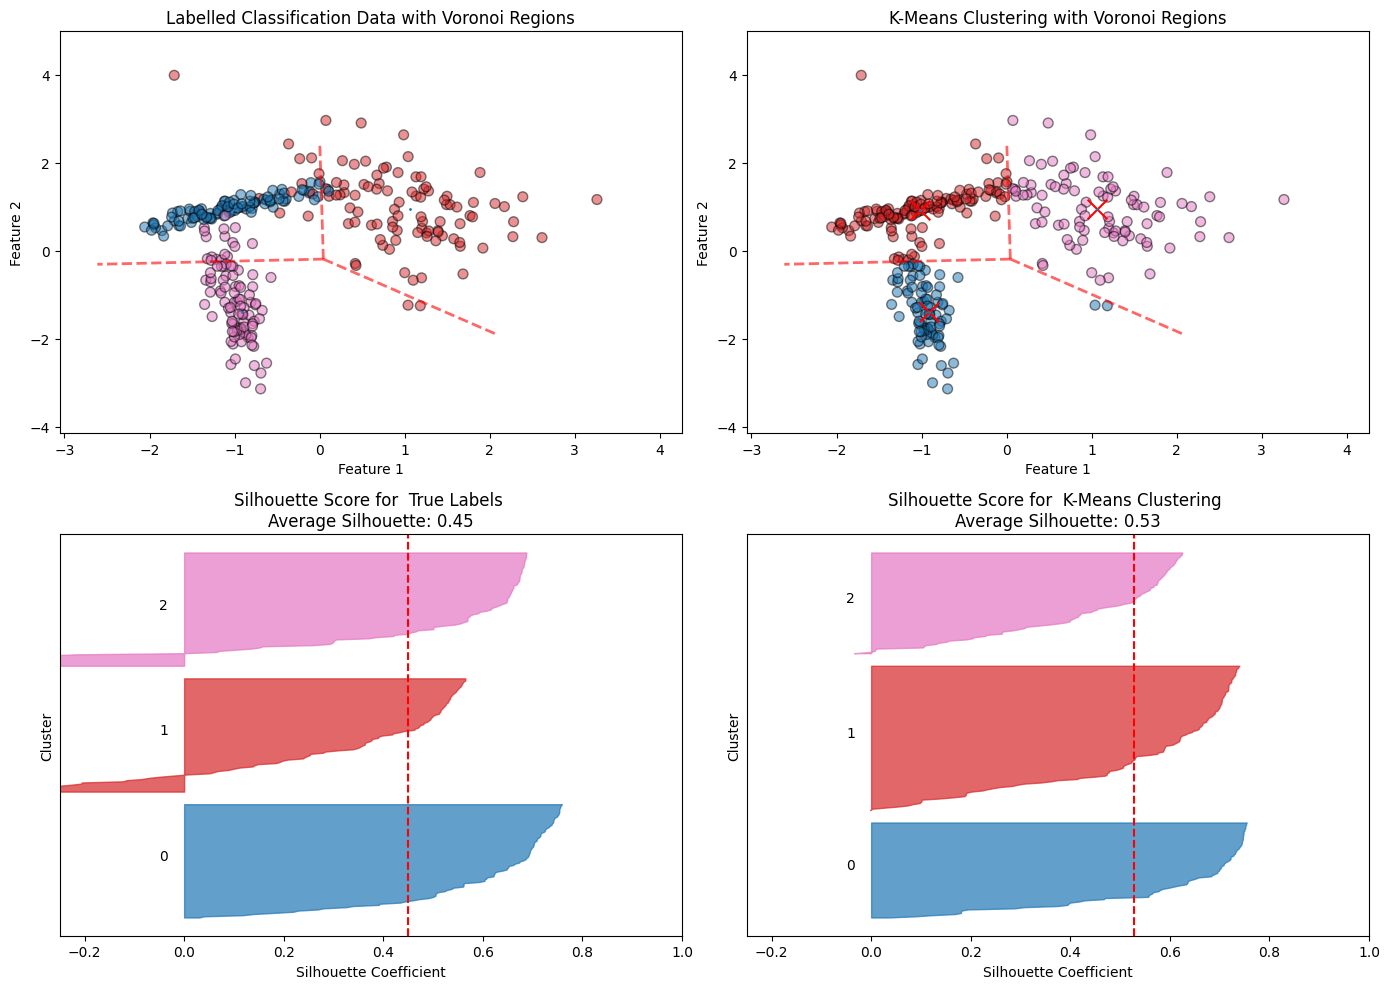

In [15]:
# Generate synthetic classification data
X, y_true = make_classification(n_samples=300, n_features=2, n_informative=2, n_redundant=0,
                                n_clusters_per_class=1, n_classes=3, random_state=42)

# Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
y_kmeans = kmeans.fit_predict(X)
centroids = kmeans.cluster_centers_

# Compute the Voronoi diagram
vor = Voronoi(centroids)

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Get consistent axis limits for all scatter plots
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

# Plot the true labels with Voronoi regions
colormap = cm.tab10
colors_true = colormap(y_true.astype(float) / 3)
axes[0, 0].scatter(X[:, 0], X[:, 1], c=colors_true, s=50, alpha=0.5, ec='k')
voronoi_plot_2d(vor, ax=axes[0, 0], show_vertices=False, line_colors='red', line_width=2, line_alpha=0.6, point_size=2)
axes[0, 0].set_title('Labelled Classification Data with Voronoi Regions')
axes[0, 0].set_xlabel('Feature 1')
axes[0, 0].set_ylabel('Feature 2')
axes[0, 0].set_xlim(x_min, x_max)
axes[0, 0].set_ylim(y_min, y_max)

# Call evaluate_clustering for true labels
evaluate_clustering(X, y_true, n_clusters=3, ax=axes[1, 0], title_suffix=' True Labels')

# Plot K-Means clustering results with Voronoi regions
colors_kmeans = colormap(y_kmeans.astype(float) / 3)
axes[0, 1].scatter(X[:, 0], X[:, 1], c=colors_kmeans, s=50, alpha=0.5, ec='k')
axes[0, 1].scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='x', label='Centroids')
voronoi_plot_2d(vor, ax=axes[0, 1], show_vertices=False, line_colors='red', line_width=2, line_alpha=0.6, point_size=2)

axes[0, 1].set_title('K-Means Clustering with Voronoi Regions')
axes[0, 1].set_xlabel('Feature 1')
axes[0, 1].set_ylabel('Feature 2')
axes[0, 1].set_xlim(x_min, x_max)
axes[0, 1].set_ylim(y_min, y_max)

# Call evaluate_clustering for K-Means labels
evaluate_clustering(X, y_kmeans, n_clusters=3, ax=axes[1, 1], title_suffix=' K-Means Clustering')

# Adjust layout and show plot
plt.tight_layout()
plt.show()


O K-means fez um bom trabalho ao identificar três clusters que concordam em grande parte com as três classes.

No entanto, observando os detalhes mais finos, o K-means não foi capaz de capturar totalmente a coerência inerente das duas classes com formato linear (roxa e azul).

Outra coisa a se notar é que os clusters são particionados de uma forma que não captura a densidade das classes.

As linhas tracejadas vermelhas nos gráficos de dispersão indicam os limites entre as regiões de "Voronoi" que separam os clusters. Este método de particionamento assume inerentemente formas esféricas para os clusters e pode classificar pontos incorretamente onde a verdadeira distribuição é curva ou linear. Por exemplo, alguns pontos pertencentes à classe roxa alongada foram classificados incorretamente, caindo na seção inferior do cluster mais esférico. De forma semelhante, os pontos azuis entre os dois clusters azul e roxo foram rotulados incorretamente.

Curiosamente, o score de silhueta (silhouette score) é maior para o resultado da clusterização do que para os rótulos reais das classes. Isso é adequado, no entanto, já que as classes reais se sobrepõem ligeiramente, como também é indicado pelos valores negativos no gráfico de silhueta para as classes rosa e vermelha.

Vá em frente e explore algumas abordagens diferentes. É claro que, em problemas de clusterização do mundo real, você não tem o benefício de saber a resposta como tivemos neste experimento, então você precisará ser criativo.

O algoritmo K-means teve um desempenho razoavelmente bom ao identificar três clusters que se alinham em grande parte com os rótulos reais das classes. No entanto, um exame mais detalhado revela que o K-means tem dificuldade em capturar com precisão a estrutura linear e alongada das duas classes (representadas em roxo e azul).

Uma limitação notável é que o K-means não contabiliza efetivamente a distribuição de densidade dos pontos. Os clusters resultantes são separados por limites de "Voronoi" (indicados pelas linhas tracejadas vermelhas), que dividem o espaço em regiões que são equidistantes aos centroides mais próximos. Essa abordagem assume inerentemente formas esféricas para os clusters e pode classificar incorretamente os pontos se a verdadeira distribuição se desviar dessa suposição.

De forma semelhante, alguns pontos azuis situados entre os clusters principais azul e roxo também foram rotulados incorretamente. Isso destaca a incapacidade do K-means de respeitar totalmente a continuidade dos dados baseada em densidade.

Uma abordagem de clusterização mais flexível, como o DBSCAN (Density-Based Spatial Clustering of Applications with Noise - Clusterização Espacial Baseada em Densidade de Aplicações com Ruído), pode ser mais adequada para esse tipo de dados. O DBSCAN leva a densidade em consideração e pode identificar clusters de formas e tamanhos variados, potencialmente capturando a verdadeira estrutura dos dados de forma mais eficaz.

Em tarefas de clusterização do mundo real, a verdade fundamental (ground truth) não é conhecida, portanto, explorar múltiplos algoritmos e adaptá-los às características específicas dos dados é essencial. Testar métodos diferentes, como DBSCAN ou clusterização hierárquica, que consideram a densidade e a proximidade de maneiras não lineares, pode fornecer resultados melhores para conjuntos de dados complexos.